# FER Challenge — Facial Expression Recognition

**Dataset:** 48×48 grayscale face images — 7 emotion classes  
**Tracking:** Wandb (Weights & Biases)  
**Architectures:** TinyCNN → MediumCNN → DeepCNN (progressive complexity)

## Setup

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import wandb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'pytorch version: {torch.__version__}')
print(f'device: {device}')

pytorch version: 2.11.0+cu128
device: cuda


## Wandb Setup

In [2]:
PROJECT_NAME   = 'FER-Challenge'
WANDB_ENTITY   = 'sansi23_team'

EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
NUM_CLASSES    = 7
IMG_SIZE       = 48
RANDOM_SEED    = 42

os.makedirs('checkpoints', exist_ok=True)

# relogin=True forces a fresh key if cached credentials are expired
wandb.login(relogin=True)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\user\_netrc.
wandb: Currently logged in as: sansi23 (sansi23_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Data Loading

In [4]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head(3)

Train shape: (28709, 2)
Test shape:  (7178, 1)


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...


In [5]:
def parse_pixels(pixel_str):
    return np.array(pixel_str.strip().split(), dtype=np.uint8).reshape(IMG_SIZE, IMG_SIZE)

X_all      = np.array([parse_pixels(p) for p in train_df['pixels']])
y_all      = train_df['emotion'].values
X_test_raw = np.array([parse_pixels(p) for p in test_df['pixels']])

print(f'X_all shape:      {X_all.shape}  dtype: {X_all.dtype}')
print(f'y_all shape:      {y_all.shape}')
print(f'X_test_raw shape: {X_test_raw.shape}')

X_all shape:      (28709, 48, 48)  dtype: uint8
y_all shape:      (28709,)
X_test_raw shape: (7178, 48, 48)


## Exploratory Data Analysis

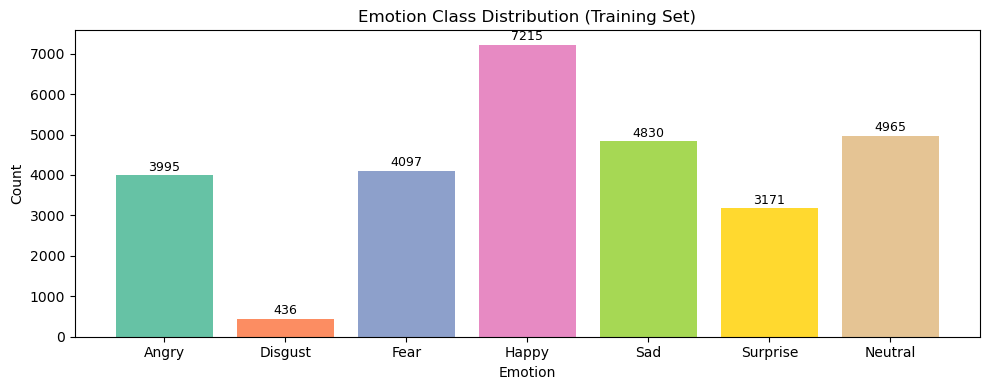


Class distribution:
  Angry     | ██████                    |  3995 (13.9%)
  Disgust   |                           |   436 (1.5%)
  Fear      | ███████                   |  4097 (14.3%)
  Happy     | ████████████              |  7215 (25.1%)
  Sad       | ████████                  |  4830 (16.8%)
  Surprise  | █████                     |  3171 (11.0%)
  Neutral   | ████████                  |  4965 (17.3%)


In [8]:
emotion_counts = pd.Series(y_all).value_counts().sort_index()
emotion_counts.index = EMOTION_LABELS

plt.figure(figsize=(10, 4))
bars = plt.bar(emotion_counts.index, emotion_counts.values,
               color=sns.color_palette('Set2', NUM_CLASSES))
for bar, count in zip(bars, emotion_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
             str(count), ha='center', va='bottom', fontsize=9)
plt.title('Emotion Class Distribution (Training Set)')
plt.ylabel('Count')
plt.xlabel('Emotion')
plt.tight_layout()
plt.show()

print('\nClass distribution:')
for label, count in zip(EMOTION_LABELS, emotion_counts.values):
    pct = count / len(y_all) * 100
    bar = chr(9608) * int(pct / 2)
    print(f'  {label:9s} | {bar:<25s} | {count:5d} ({pct:.1f}%)')

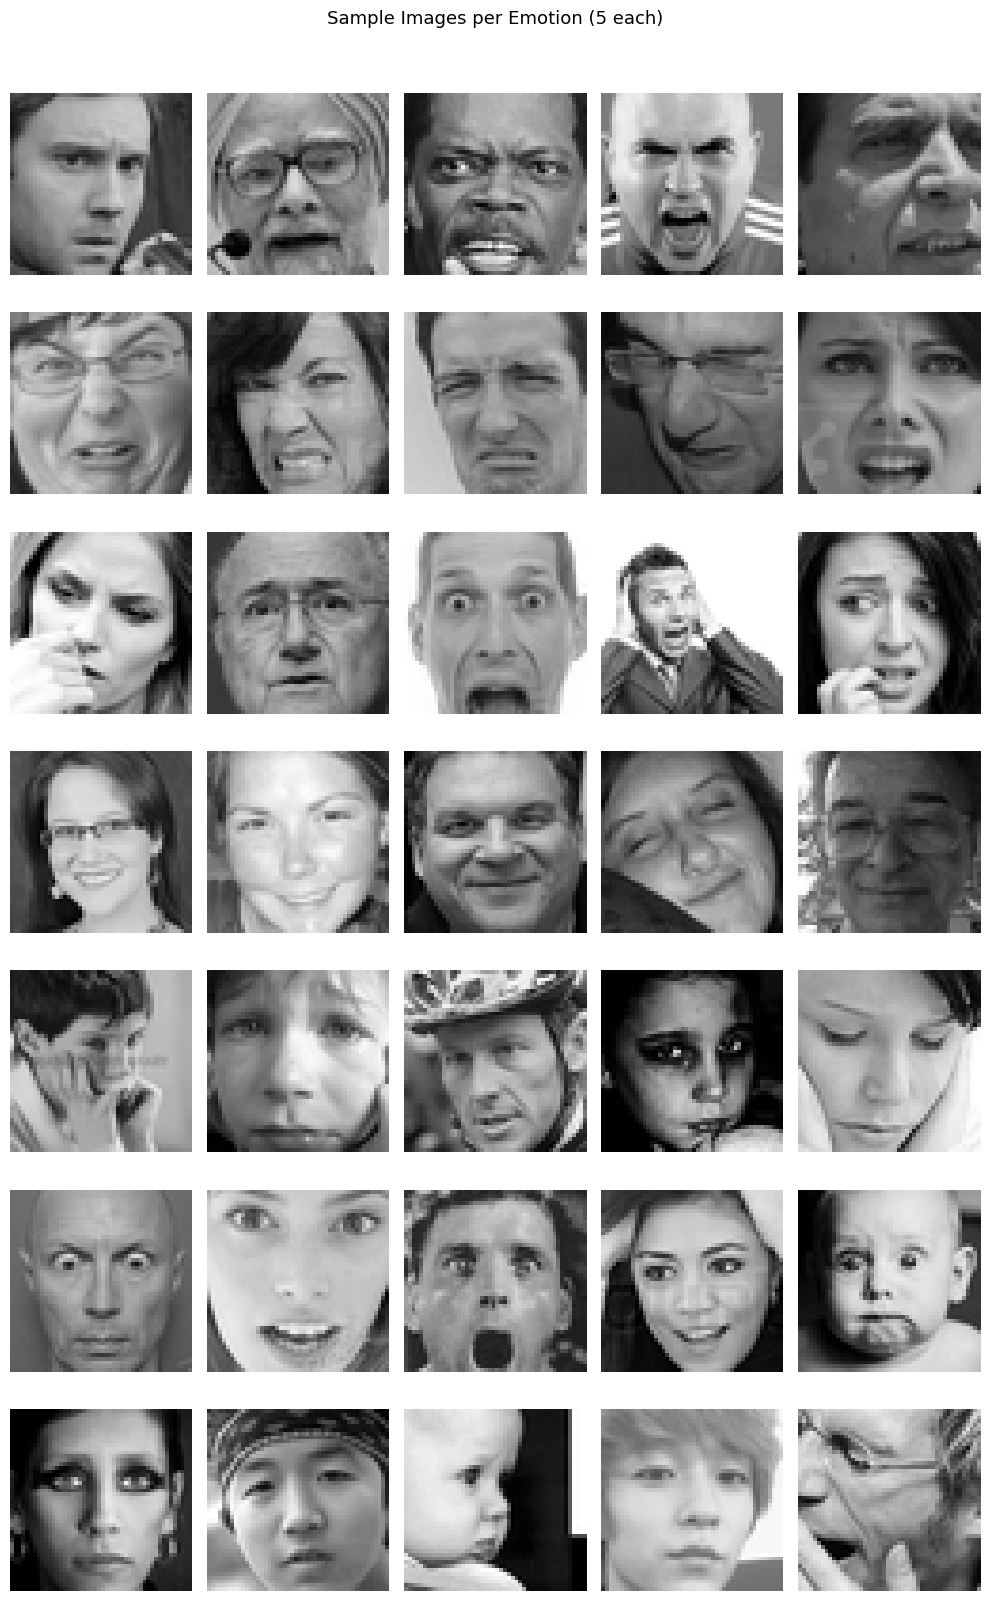

In [9]:
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(10, 16))
for emo_idx in range(NUM_CLASSES):
    samples = X_all[y_all == emo_idx][:5]
    for j in range(5):
        axes[emo_idx, j].imshow(samples[j], cmap='gray', vmin=0, vmax=255)
        axes[emo_idx, j].axis('off')
    axes[emo_idx, 0].set_ylabel(EMOTION_LABELS[emo_idx], fontsize=10,
                                rotation=0, labelpad=50, va='center')
plt.suptitle('Sample Images per Emotion (5 each)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

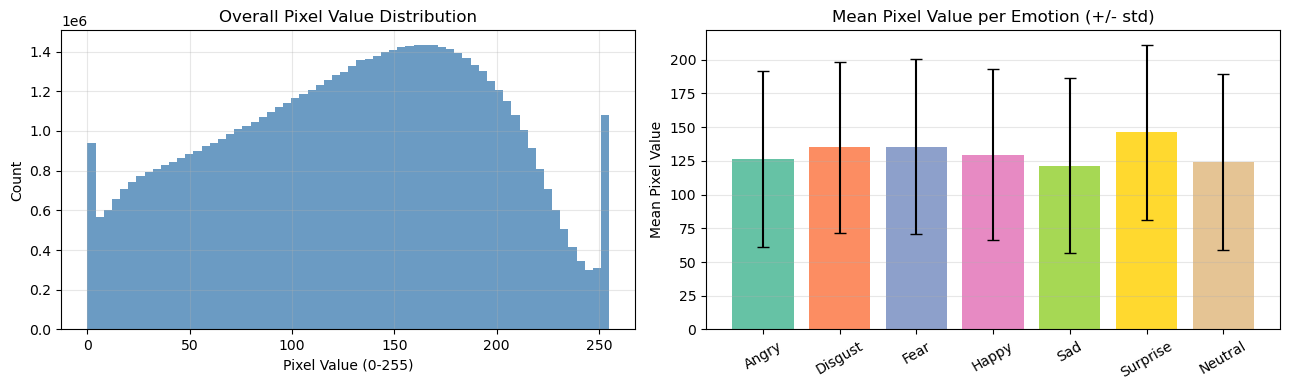

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(X_all.flatten(), bins=64, color='steelblue', alpha=0.8)
axes[0].set_title('Overall Pixel Value Distribution')
axes[0].set_xlabel('Pixel Value (0-255)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

mean_pixels = [X_all[y_all == i].mean() for i in range(NUM_CLASSES)]
std_pixels  = [X_all[y_all == i].std()  for i in range(NUM_CLASSES)]
axes[1].bar(EMOTION_LABELS, mean_pixels,
            color=sns.color_palette('Set2', NUM_CLASSES),
            yerr=std_pixels, capsize=4)
axes[1].set_title('Mean Pixel Value per Emotion (+/- std)')
axes[1].set_ylabel('Mean Pixel Value')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_all
)

print(f'Train set:      {X_train.shape}')
print(f'Validation set: {X_val.shape}')
print(f'Test set:       {X_test_raw.shape}')

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weights = torch.FloatTensor(class_weights_np)

print('\nClass weights (balanced):')
for label, w in zip(EMOTION_LABELS, class_weights_np):
    print(f'  {label:9s}: {w:.4f}')

Train set:      (22967, 48, 48)
Validation set: (5742, 48, 48)
Test set:       (7178, 48, 48)

Class weights (balanced):
  Angry    : 1.0266
  Disgust  : 9.4011
  Fear     : 1.0012
  Happy    : 0.5684
  Sad      : 0.8491
  Surprise : 1.2933
  Neutral  : 0.8260


## Dataset & DataLoaders

In [7]:
class FERDataset(Dataset):

    def __init__(self, images, labels=None, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx], mode='L')
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        if self.labels is not None:
            return img, torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return img


def get_transforms(augment=False):
    base = [transforms.ToTensor(), transforms.Normalize([0.5], [0.5])]
    if augment:
        aug = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        ]
        return transforms.Compose(aug + base), transforms.Compose(base)
    return transforms.Compose(base), transforms.Compose(base)


def get_dataloaders(X_tr, y_tr, X_v, y_v, batch_size, augment=False, use_sampler=False):
    train_tf, val_tf = get_transforms(augment)

    if use_sampler:
        class_counts = np.bincount(y_tr)
        sample_weights = torch.FloatTensor([1.0 / class_counts[y] for y in y_tr])
        sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))
        train_loader = DataLoader(
            FERDataset(X_tr, y_tr, train_tf),
            batch_size=batch_size, sampler=sampler,
            num_workers=0, pin_memory=torch.cuda.is_available()
        )
    else:
        train_loader = DataLoader(
            FERDataset(X_tr, y_tr, train_tf),
            batch_size=batch_size, shuffle=True,
            num_workers=0, pin_memory=torch.cuda.is_available()
        )

    val_loader = DataLoader(
        FERDataset(X_v, y_v, val_tf),
        batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=torch.cuda.is_available()
    )
    return train_loader, val_loader


print('FERDataset and DataLoader utilities defined')

FERDataset and DataLoader utilities defined


## Model Architectures

| Architecture  | Params  | Purpose |
|---|---|---|
| **TinyCNN**   | ~148 K  | Demonstrate **underfitting** |
| **MediumCNN** | ~1.2 M  | Show **overfitting without regularisation**, then fix it |
| **DeepCNN**   | ~2.8 M  | Best capacity with **augmentation + Dropout2d** |

In [ ]:
class TinyCNN(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  8, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 12 * 12, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, NUM_CLASSES),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class MediumCNN(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,   32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class DeepCNN(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout),
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout),
            nn.Conv2d(64,  128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, NUM_CLASSES),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f'TinyCNN   params: {count_params(TinyCNN()):>10,}')
print(f'MediumCNN params: {count_params(MediumCNN()):>10,}')
print(f'DeepCNN   params: {count_params(DeepCNN()):>10,}')

TinyCNN   params:    149,223
MediumCNN params:  1,275,335
DeepCNN   params:  2,651,751


## Training & Evaluation Utilities

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(images)
        correct    += outputs.argmax(dim=1).eq(labels).sum().item()
        total      += len(images)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * len(images)
        preds = outputs.argmax(dim=1)
        correct  += preds.eq(labels).sum().item()
        total    += len(images)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def plot_history(history, run_name, arch_tag):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='orange')
    axes[0].set_title(f'{run_name} - Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_acc'], label='Train Acc', color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Val Acc',   color='orange')
    axes[1].set_title(f'{run_name} - Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'[{arch_tag}] Training Curves', fontsize=13)
    plt.tight_layout()
    plt.show()


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


print('Training utilities defined')

Training utilities defined


In [22]:
all_results          = []
global_best_val_acc  = 0.0
global_best_run_name = None


def run_experiment(model_class, params, run_name, arch_tag):
    global global_best_val_acc, global_best_run_name

    seed = params.get('seed', RANDOM_SEED)
    set_seed(seed)

    print(f'\n{"="*65}')
    print(f'Run: {run_name}')
    print(f'Params: {params}')
    print(f'{"="*65}')

    train_loader, val_loader = get_dataloaders(
        X_train, y_train, X_val, y_val,
        batch_size=params['batch_size'],
        augment=params.get('augment', False),
        use_sampler=params.get('use_sampler', False)
    )

    model     = model_class(dropout=params.get('dropout', 0.0)).to(device)
    opt_name = params.get('optimizer', 'adamw').lower()
    if opt_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=params['lr'],
                              weight_decay=params.get('weight_decay', 1e-4),
                              momentum=0.9, nesterov=True)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=params['lr'],
                                weight_decay=params.get('weight_decay', 1e-4))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device),
        label_smoothing=params.get('label_smoothing', 0.0)
    )

    run = wandb.init(
        project=PROJECT_NAME,
        entity=WANDB_ENTITY,
        name=run_name,
        config={**params, 'architecture': arch_tag, 'n_params': count_params(model), 'seed': seed},
        tags=[arch_tag],
        reinit=True
    )

    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(params['epochs']):
        tr_loss, tr_acc         = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, _, _   = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_acc)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        wandb.log({
            'epoch':       epoch + 1,
            'train_loss':  tr_loss,
            'train_acc':   tr_acc,
            'val_loss':    vl_loss,
            'val_acc':     vl_acc,
            'overfit_gap': tr_acc - vl_acc,
            'lr':          optimizer.param_groups[0]['lr'],
        })

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'checkpoints/{run_name}_best.pth')

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d}/{params["epochs"]} | '
                  f'train_loss={tr_loss:.4f} | train_acc={tr_acc:.4f} | '
                  f'val_loss={vl_loss:.4f} | val_acc={vl_acc:.4f}')

    model.load_state_dict(torch.load(f'checkpoints/{run_name}_best.pth', map_location=device))
    _, _, val_preds, val_true = evaluate(model, val_loader, criterion, device)

    wandb.log({
        'conf_mat': wandb.plot.confusion_matrix(
            y_true=val_true.tolist(),
            preds=val_preds.tolist(),
            class_names=EMOTION_LABELS
        )
    })
    wandb.summary['best_val_acc']    = best_val_acc
    wandb.summary['final_train_acc'] = history['train_acc'][-1]
    wandb.summary['overfit_gap']     = history['train_acc'][-1] - best_val_acc
    run.finish()

    result = {
        'run_name':        run_name,
        'architecture':    arch_tag,
        'lr':              params['lr'],
        'dropout':         params.get('dropout', 0.0),
        'batch_size':      params['batch_size'],
        'augment':         params.get('augment', False),
        'use_sampler':     params.get('use_sampler', False),
        'weight_decay':    params.get('weight_decay', 1e-4),
        'optimizer':       params.get('optimizer', 'adamw'),
        'label_smoothing': params.get('label_smoothing', 0.0),
        'seed':            seed,
        'best_val_acc':    best_val_acc,
        'final_train_acc': history['train_acc'][-1],
        'overfit_gap':     history['train_acc'][-1] - best_val_acc,
    }
    all_results.append(result)

    if best_val_acc > global_best_val_acc:
        global_best_val_acc  = best_val_acc
        global_best_run_name = run_name

    print(f'  best_val_acc={best_val_acc:.4f} | overfit_gap={history["train_acc"][-1] - best_val_acc:.4f}')
    return history


print('run_experiment() defined')

run_experiment() defined


## Architecture 1 - Tiny CNN

**Hypothesis (Forward Checking):** Start with the simplest possible CNN to verify the pipeline and observe underfitting.

TinyCNN has only 2 conv layers and a 64-unit FC head (~148K params). Too few feature maps for 7-class emotion recognition.

**Expected:** Both train and val accuracy plateau low (~40-50%) — classic underfitting.  
**Experiments:** Vary learning rate.

In [30]:
param_grid_tiny = [
    {'lr': 0.01,   'epochs': 25, 'batch_size': 64, 'dropout': 0.0, 'augment': False},
    {'lr': 0.001,  'epochs': 25, 'batch_size': 64, 'dropout': 0.0, 'augment': False},
    {'lr': 0.0001, 'epochs': 25, 'batch_size': 64, 'dropout': 0.0, 'augment': False},
]

arch1_histories = {}
for params in param_grid_tiny:
    run_name = f'TinyCNN_lr{params["lr"]}_bs{params["batch_size"]}'
    arch1_histories[run_name] = run_experiment(TinyCNN, params, run_name, arch_tag='TinyCNN')


Run: TinyCNN_lr0.01_bs64
Params: {'lr': 0.01, 'epochs': 25, 'batch_size': 64, 'dropout': 0.0, 'augment': False}


  Epoch   5/25 | train_loss=1.9462 | train_acc=0.1656 | val_loss=1.9447 | val_acc=0.1392
  Epoch  10/25 | train_loss=1.9463 | train_acc=0.1575 | val_loss=1.9451 | val_acc=0.1392
  Epoch  15/25 | train_loss=1.9453 | train_acc=0.1716 | val_loss=1.9447 | val_acc=0.1682
  Epoch  20/25 | train_loss=1.9453 | train_acc=0.1475 | val_loss=1.9446 | val_acc=0.2513
  Epoch  25/25 | train_loss=1.9453 | train_acc=0.2228 | val_loss=1.9446 | val_acc=0.2513


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,█████████▄▄▄▄▄▄▂▂▂▂▂▂▂▁▁▁
overfit_gap,▇█▇▅▇▅▇▇█▆▅▇▇▇▆▆▁▆▇▁▅▆▂▆▄
train_acc,▁▂▃▂▂▂▄▃▂▂▂▃▄▄▃▁▂▃▄▁▂▄▃█▆
train_loss,█▃▃▄▃▄▃▃▄▄▃▂▂▂▁▂▂▁▁▁▁▁▃▁▁
val_acc,▁▁▃▄▂▄▃▃▁▂▄▃▄▄▄▂█▄▄█▄▄███
val_loss,▆▆▆▄▂▃▄▅█▄▂▂▃▂▁▂▁▁▁▁▂▄▂▁▁
best_val_acc,0.25131
epoch,25
final_train_acc,0.22275
lr,0.00125


  best_val_acc=0.2513 | overfit_gap=-0.0286

Run: TinyCNN_lr0.001_bs64
Params: {'lr': 0.001, 'epochs': 25, 'batch_size': 64, 'dropout': 0.0, 'augment': False}


  Epoch   5/25 | train_loss=1.3396 | train_acc=0.4789 | val_loss=1.4714 | val_acc=0.4586
  Epoch  10/25 | train_loss=1.0170 | train_acc=0.5812 | val_loss=1.5562 | val_acc=0.4751
  Epoch  15/25 | train_loss=0.8205 | train_acc=0.6560 | val_loss=1.8194 | val_acc=0.4899
  Epoch  20/25 | train_loss=0.6634 | train_acc=0.7256 | val_loss=2.1647 | val_acc=0.4734
  Epoch  25/25 | train_loss=0.4580 | train_acc=0.8164 | val_loss=2.6858 | val_acc=0.4965


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,█████████████████████▁▁▁▁
overfit_gap,▁▃▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇███
train_acc,▁▂▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
train_loss,█▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
val_acc,▁▁▄▅▅▆▆▇▇▇▅▇▇███▇▇▇▆▇█▇██
val_loss,▃▂▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▅▅▅▆▆▇██
best_val_acc,0.49652
epoch,25
final_train_acc,0.81639
lr,0.0005


  best_val_acc=0.4965 | overfit_gap=0.3199

Run: TinyCNN_lr0.0001_bs64
Params: {'lr': 0.0001, 'epochs': 25, 'batch_size': 64, 'dropout': 0.0, 'augment': False}


  Epoch   5/25 | train_loss=1.7253 | train_acc=0.3461 | val_loss=1.7325 | val_acc=0.3239
  Epoch  10/25 | train_loss=1.6473 | train_acc=0.3762 | val_loss=1.6715 | val_acc=0.3741
  Epoch  15/25 | train_loss=1.5745 | train_acc=0.4004 | val_loss=1.6210 | val_acc=0.3910
  Epoch  20/25 | train_loss=1.5094 | train_acc=0.4238 | val_loss=1.5856 | val_acc=0.4215
  Epoch  25/25 | train_loss=1.4548 | train_acc=0.4412 | val_loss=1.5536 | val_acc=0.4323


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▄██▆▆▄▃▅█▅▄▆▆▇▇▆▆▅▆▇██▆
train_acc,▁▃▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█████
train_loss,█▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
val_acc,▁▃▄▄▄▅▅▅▆▆▅▆▇▆▆▆▆▇▇█▇▇▇▇█
val_loss,█▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▃▂▂▂▁▁▁▁
best_val_acc,0.43225
epoch,25
final_train_acc,0.44115
lr,0.0001


  best_val_acc=0.4323 | overfit_gap=0.0089


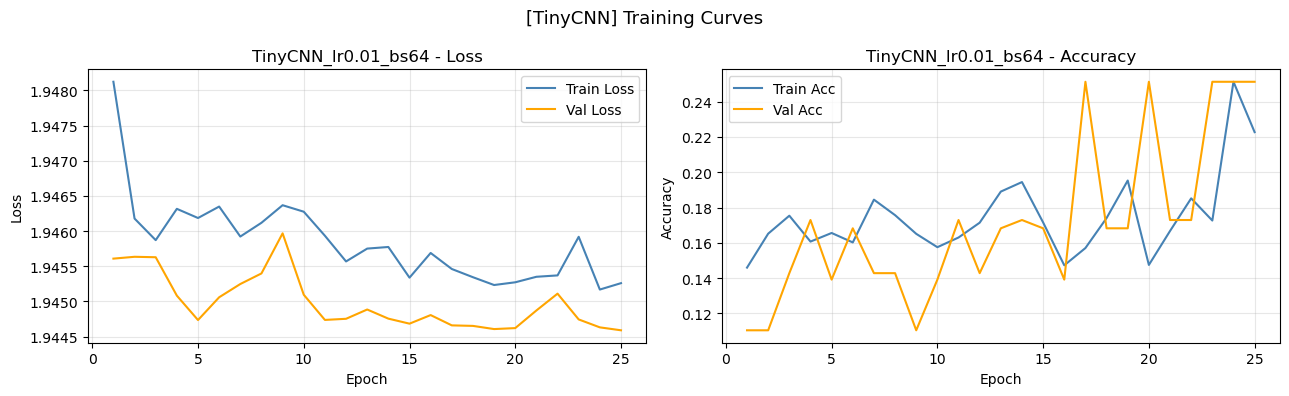

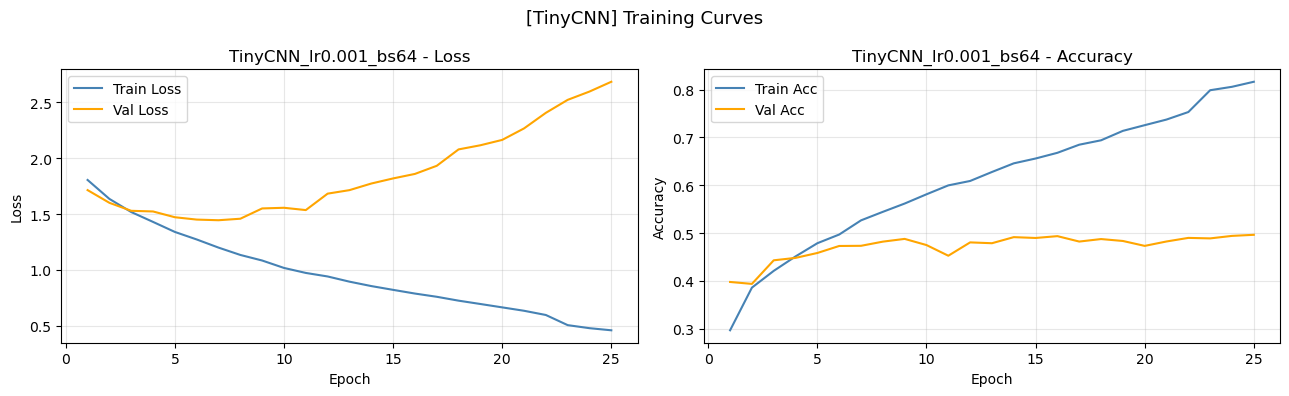

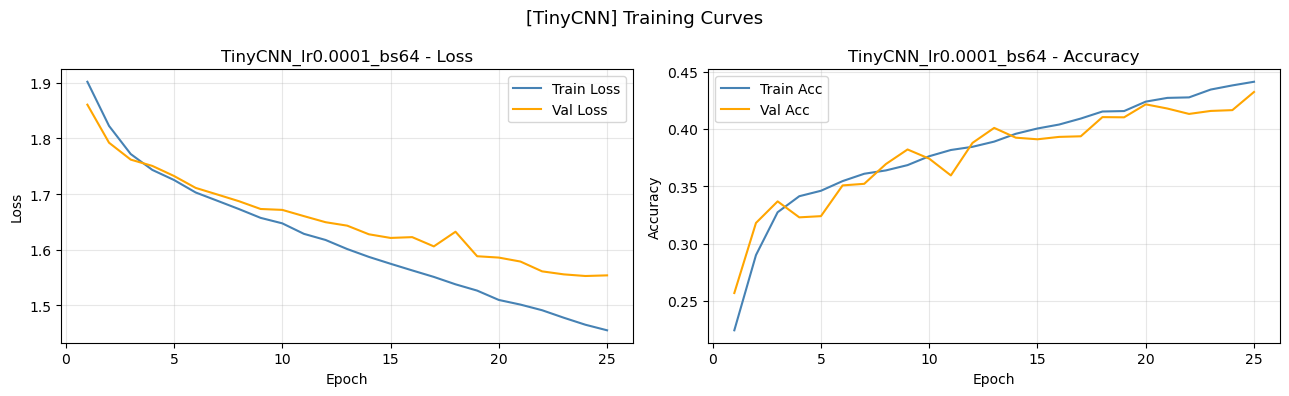

Architecture 1 - Summary:
             run_name     lr  best_val_acc  final_train_acc  overfit_gap
  TinyCNN_lr0.01_bs64 0.0100      0.251306         0.222754    -0.028552
 TinyCNN_lr0.001_bs64 0.0010      0.496517         0.816389     0.319872
TinyCNN_lr0.0001_bs64 0.0001      0.432254         0.441155     0.008901

Analysis - TinyCNN:
  * Both train_acc and val_acc are low -> underfitting confirmed
  * Small overfit_gap only because the model cannot fit the training data either
  * Forward checking shows the model learns something, but capacity is insufficient
  * Decision: increase model capacity -> MediumCNN



In [31]:
for run_name, hist in arch1_histories.items():
    plot_history(hist, run_name, 'TinyCNN')

df1 = pd.DataFrame([r for r in all_results if r['architecture'] == 'TinyCNN'])
print('Architecture 1 - Summary:')
print(df1[['run_name', 'lr', 'best_val_acc', 'final_train_acc', 'overfit_gap']].to_string(index=False))
print("""
Analysis - TinyCNN:
  * Both train_acc and val_acc are low -> underfitting confirmed
  * Small overfit_gap only because the model cannot fit the training data either
  * Forward checking shows the model learns something, but capacity is insufficient
  * Decision: increase model capacity -> MediumCNN
""")

## Architecture 2 - Medium CNN

**Hypothesis (Backward Checking):** Increase capacity to fix underfitting, then apply backward checking to control overfitting.

MediumCNN: 3 conv blocks (1->32->64->128 channels) with BatchNorm, ~1.2M params.

**Strategy:**
1. `dropout=0.0` — no regularisation -> overfitting (train >> val)
2. Backward checking: add dropout progressively -> overfit gap shrinks
3. Add augmentation -> further improvement

In [32]:
param_grid_medium = [
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.0, 'augment': False},
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.3, 'augment': False},
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.5, 'augment': False},
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.4, 'augment': True},
]

arch2_histories = {}
for params in param_grid_medium:
    run_name = f'MediumCNN_lr{params["lr"]}_drop{params["dropout"]}_aug{params["augment"]}'
    arch2_histories[run_name] = run_experiment(MediumCNN, params, run_name, arch_tag='MediumCNN')


Run: MediumCNN_lr0.001_drop0.0_augFalse
Params: {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.0, 'augment': False}


  Epoch   5/35 | train_loss=0.6971 | train_acc=0.7260 | val_loss=1.3292 | val_acc=0.5481
  Epoch  10/35 | train_loss=0.1411 | train_acc=0.9591 | val_loss=1.9894 | val_acc=0.5529
  Epoch  15/35 | train_loss=0.0741 | train_acc=0.9822 | val_loss=2.2571 | val_acc=0.5510
  Epoch  20/35 | train_loss=0.0747 | train_acc=0.9814 | val_loss=2.2237 | val_acc=0.5644
  Epoch  25/35 | train_loss=0.0244 | train_acc=0.9963 | val_loss=2.1980 | val_acc=0.5829
  Epoch  30/35 | train_loss=0.0154 | train_acc=0.9973 | val_loss=2.1360 | val_acc=0.5885
  Epoch  35/35 | train_loss=0.0151 | train_acc=0.9973 | val_loss=2.1619 | val_acc=0.5831


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,███████████████████▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁
overfit_gap,▁▂▃▄▅▅▆▇▇██▇███████████████████████
train_acc,▁▂▃▄▅▆▆▇▇██▇███████████████████████
train_loss,█▇▆▅▄▃▃▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁
val_acc,▁▃▅▅▅▆▆▇▆▆▆▆▇▇▅▄▅▆▇▆▇██▇█▆▆▇▇██████
val_loss,▂▁▁▁▁▂▃▄▄▆▇▆▆▇███▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇▇▇
best_val_acc,0.58847
epoch,35
final_train_acc,0.99726
lr,0.00025


  best_val_acc=0.5885 | overfit_gap=0.4088

Run: MediumCNN_lr0.001_drop0.3_augFalse
Params: {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.3, 'augment': False}


  Epoch   5/35 | train_loss=0.8496 | train_acc=0.6590 | val_loss=1.2122 | val_acc=0.5554
  Epoch  10/35 | train_loss=0.3153 | train_acc=0.8776 | val_loss=1.6971 | val_acc=0.5630
  Epoch  15/35 | train_loss=0.1688 | train_acc=0.9388 | val_loss=2.2064 | val_acc=0.5651
  Epoch  20/35 | train_loss=0.0431 | train_acc=0.9890 | val_loss=2.2831 | val_acc=0.5719
  Epoch  25/35 | train_loss=0.0499 | train_acc=0.9861 | val_loss=2.5893 | val_acc=0.5617
  Epoch  30/35 | train_loss=0.0194 | train_acc=0.9952 | val_loss=2.5215 | val_acc=0.5765
  Epoch  35/35 | train_loss=0.0133 | train_acc=0.9970 | val_loss=2.6682 | val_acc=0.5745


...

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,██████████████▄▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁▁
overfit_gap,▁▂▂▂▃▃▄▄▅▅▆▆▆▆▇▇▇██████████████████
train_acc,▁▂▃▃▄▄▄▅▅▆▆▆▆▇▇▇███████████████████
train_loss,█▇▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▄▆▅█▇██▇███▇▇████▇█▇▇██████████▇█
val_loss,▂▂▁▁▁▁▁▁▂▂▃▃▃▃▄▄▄▅▆▆▆▇▇▆▇▇▇█▇█▇████
best_val_acc,0.58847
epoch,35
final_train_acc,0.99517
lr,6e-05


  best_val_acc=0.5885 | overfit_gap=0.4067

Run: MediumCNN_lr0.001_drop0.4_augTrue
Params: {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.4, 'augment': True}


  Epoch   5/35 | train_loss=1.4041 | train_acc=0.4677 | val_loss=1.2951 | val_acc=0.5150
  Epoch  10/35 | train_loss=1.2722 | train_acc=0.5174 | val_loss=1.1902 | val_acc=0.5411
  Epoch  15/35 | train_loss=1.1824 | train_acc=0.5434 | val_loss=1.1301 | val_acc=0.5817
  Epoch  20/35 | train_loss=1.1269 | train_acc=0.5649 | val_loss=1.0939 | val_acc=0.6000
  Epoch  25/35 | train_loss=1.0767 | train_acc=0.5794 | val_loss=1.0962 | val_acc=0.6034
  Epoch  30/35 | train_loss=1.0449 | train_acc=0.5873 | val_loss=1.0815 | val_acc=0.6088
  Epoch  35/35 | train_loss=1.0235 | train_acc=0.5967 | val_loss=1.0666 | val_acc=0.6061


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▅▄▅▄▅▆▆▅▆▇▄▄▅▅▅█▆▅▅▅▅▆▆▆▆▅▆▆▆▆▆▆▆▇
train_acc,▁▃▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇█████████
train_loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▅▅▅▅▆▆▆▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇████████▇
val_loss,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▂▁▁▁▁▂▁▁▁▁
best_val_acc,0.62382
epoch,35
final_train_acc,0.59673
lr,0.001


  best_val_acc=0.6238 | overfit_gap=-0.0271


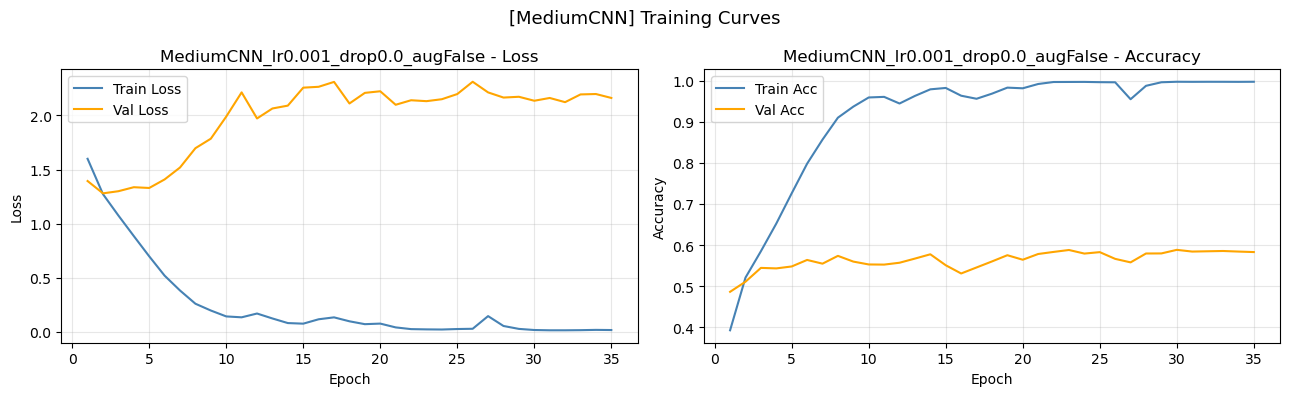

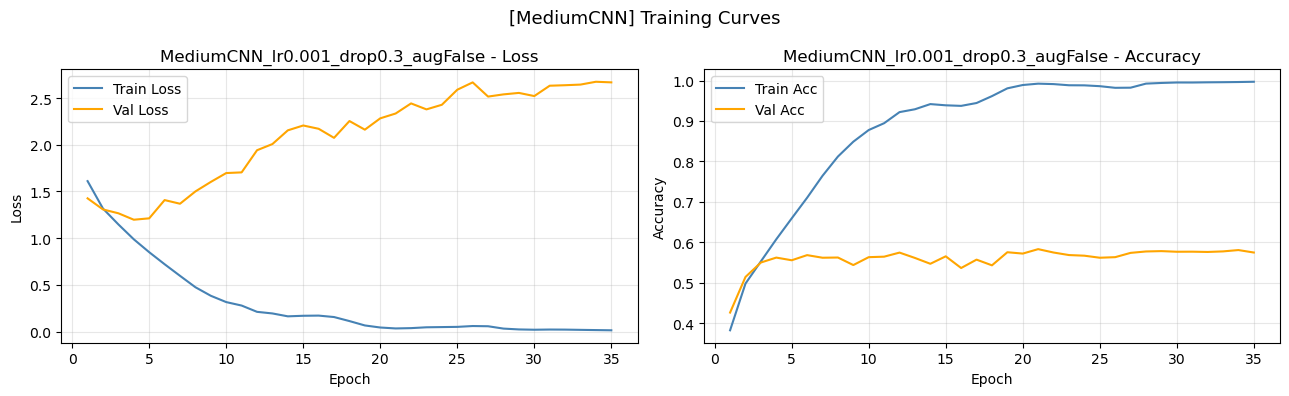

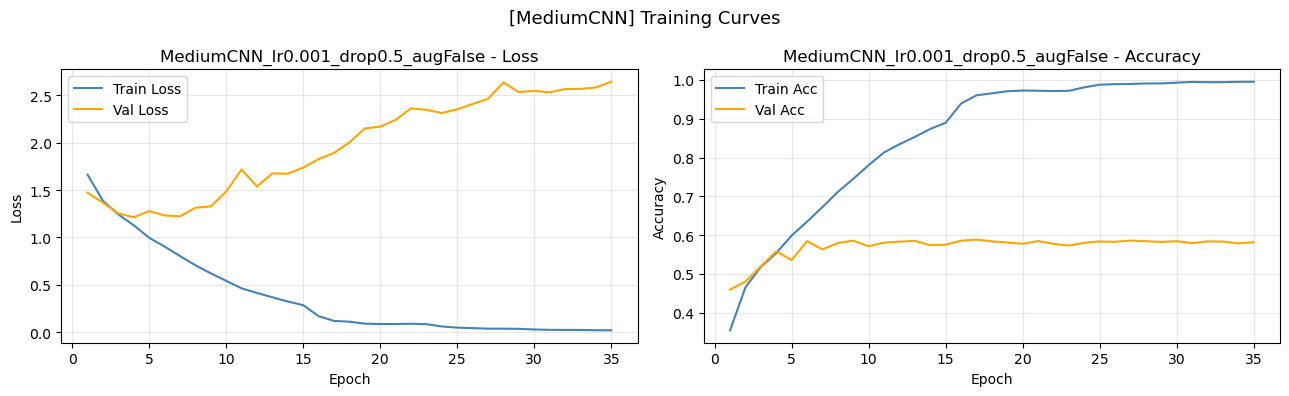

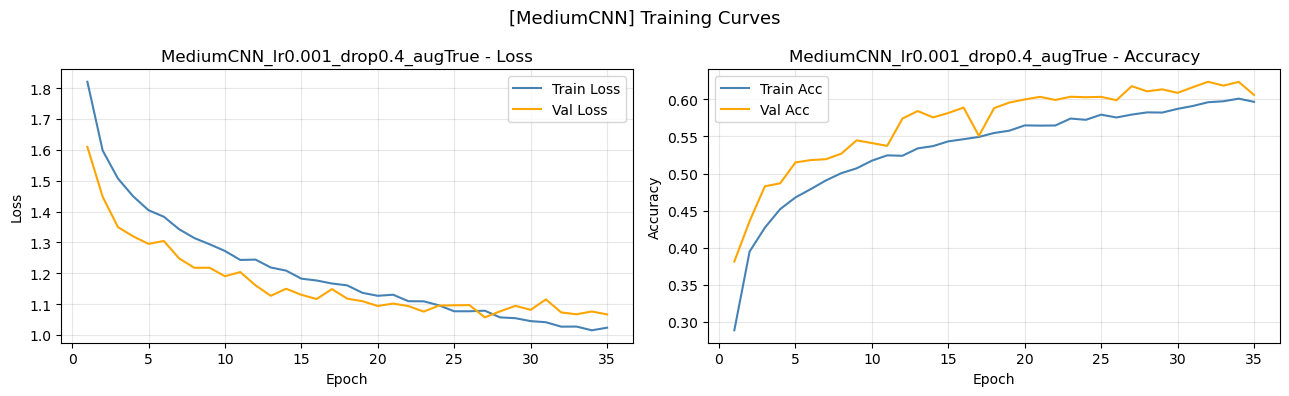

Architecture 2 - Summary:
                          run_name  dropout  augment  best_val_acc  final_train_acc  overfit_gap
MediumCNN_lr0.001_drop0.0_augFalse      0.0    False      0.588471         0.997257     0.408786
MediumCNN_lr0.001_drop0.3_augFalse      0.3    False      0.582898         0.997039     0.414141
MediumCNN_lr0.001_drop0.5_augFalse      0.5    False      0.588471         0.995167     0.406696
 MediumCNN_lr0.001_drop0.4_augTrue      0.4     True      0.623824         0.596726    -0.027099

Analysis - MediumCNN:
  * dropout=0.0: large overfit_gap (train_acc >> val_acc) -> overfitting confirmed
  * Backward checking: increasing dropout progressively reduces the overfit_gap
  * Augmentation provides further regularisation via more diverse training examples
  * Decision: go deeper with proper regularisation from the start -> DeepCNN



In [33]:
for run_name, hist in arch2_histories.items():
    plot_history(hist, run_name, 'MediumCNN')

df2 = pd.DataFrame([r for r in all_results if r['architecture'] == 'MediumCNN'])
print('Architecture 2 - Summary:')
print(df2[['run_name', 'dropout', 'augment', 'best_val_acc', 'final_train_acc', 'overfit_gap']].to_string(index=False))
print("""
Analysis - MediumCNN:
  * dropout=0.0: large overfit_gap (train_acc >> val_acc) -> overfitting confirmed
  * Backward checking: increasing dropout progressively reduces the overfit_gap
  * Augmentation provides further regularisation via more diverse training examples
  * Decision: go deeper with proper regularisation from the start -> DeepCNN
""")

## Architecture 3 - Deep CNN

**Hypothesis:** A deeper model (double-conv blocks, ~2.8M params) with regularisation from the start achieves best generalisation.

DeepCNN uses VGG-style double convolution blocks plus spatial `Dropout2d` after each block.

**Experiments:** No augmentation vs augmentation vs stronger regularisation.

In [ ]:
param_grid_deep = [
    {'lr': 0.001, 'epochs': 40, 'batch_size': 64, 'dropout': 0.25, 'augment': False},
    {'lr': 0.001, 'epochs': 40, 'batch_size': 64, 'dropout': 0.25, 'augment': True},
    {'lr': 0.001, 'epochs': 40, 'batch_size': 32, 'dropout': 0.4,  'augment': True},
    {'lr': 0.001, 'epochs': 40, 'batch_size': 64, 'dropout': 0.25, 'augment': True, 'use_sampler': True},
]

arch3_histories = {}
for params in param_grid_deep:
    sampler_tag = 'samplerTrue' if params.get('use_sampler', False) else 'samplerFalse'
    run_name = (f'DeepCNN_lr{params["lr"]}_drop{params["dropout"]}'
                f'_bs{params["batch_size"]}_aug{params["augment"]}_{sampler_tag}')
    arch3_histories[run_name] = run_experiment(DeepCNN, params, run_name, arch_tag='DeepCNN')


In [ ]:
seed_check_base = {
    'lr': 0.001, 'epochs': 40, 'batch_size': 64,
    'dropout': 0.25, 'augment': True,
}
seed_variance_histories = {}
for seed in [42, 123, 999]:
    run_name = f'DeepCNN_drop0.25_augTrue_seed{seed}'
    params   = {**seed_check_base, 'seed': seed}
    seed_variance_histories[run_name] = run_experiment(
        DeepCNN, params, run_name, arch_tag='DeepCNN'
    )


In [ ]:
param_grid_medium_wd = [
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.0, 'augment': False, 'weight_decay': 1e-4, 'seed': 42},
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.3, 'augment': False, 'weight_decay': 1e-4, 'seed': 42},
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.5, 'augment': False, 'weight_decay': 1e-4, 'seed': 42},
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.0, 'augment': False, 'weight_decay': 1e-3, 'seed': 42},
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.3, 'augment': False, 'weight_decay': 1e-3, 'seed': 42},
    {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.5, 'augment': False, 'weight_decay': 1e-3, 'seed': 42},
]
arch2_wd_histories = {}
for p in param_grid_medium_wd:
    wd_tag   = f"wd{p['weight_decay']:.0e}".replace('e-0', 'e-')
    run_name = f"MediumCNN_drop{p['dropout']}_augFalse_{wd_tag}_adamw"
    arch2_wd_histories[run_name] = run_experiment(
        MediumCNN, p, run_name, arch_tag='MediumCNN'
    )


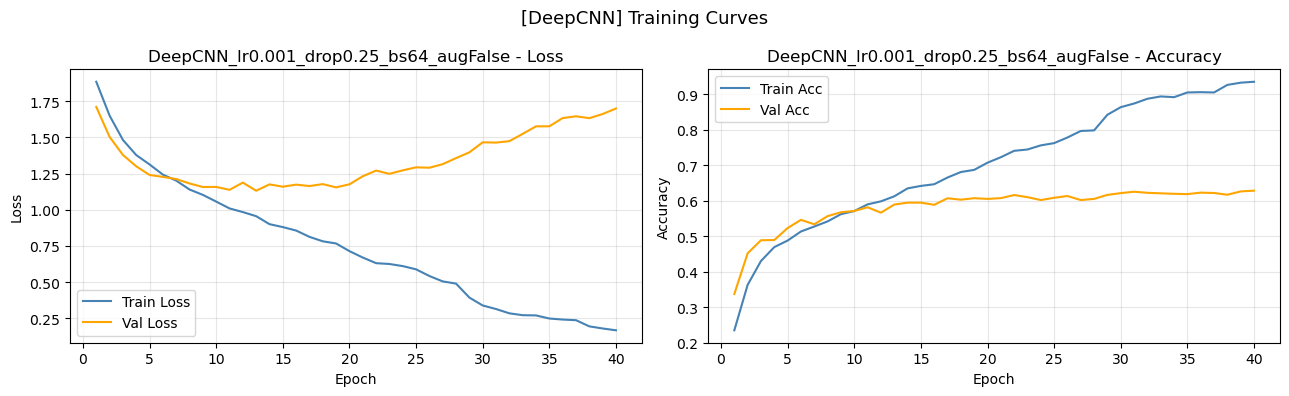

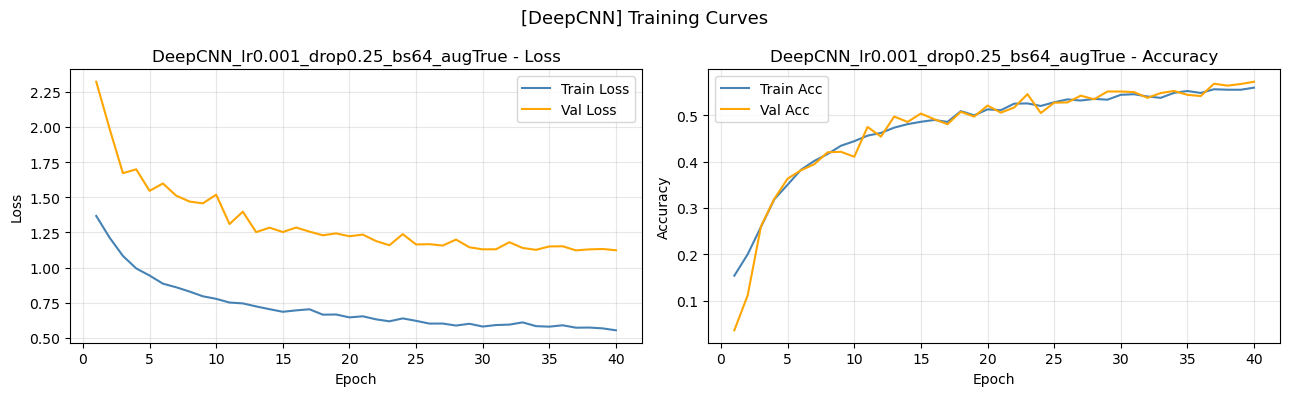

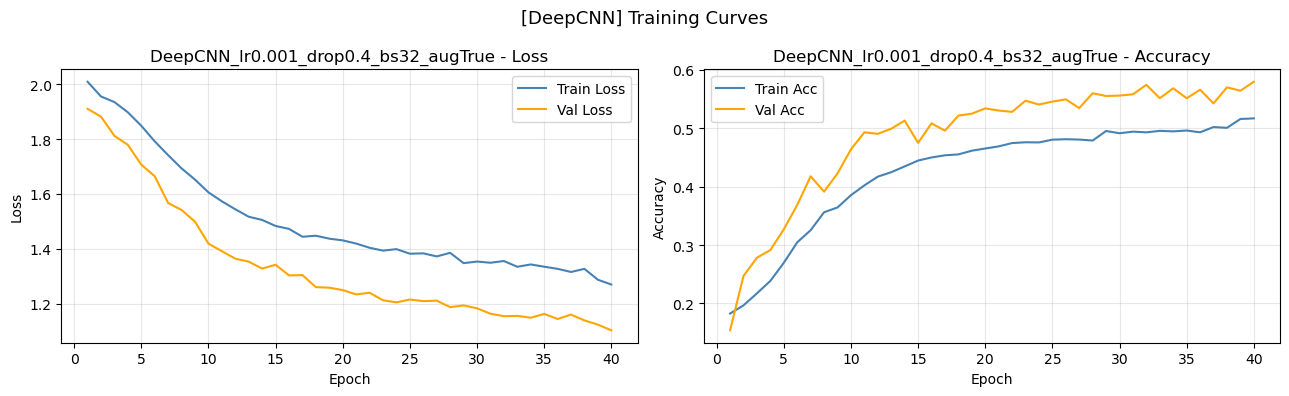

Architecture 3 - Summary:
                              run_name  dropout  augment  batch_size  best_val_acc  final_train_acc  overfit_gap
DeepCNN_lr0.001_drop0.25_bs64_augFalse     0.25    False          64      0.628352         0.935124     0.306772
 DeepCNN_lr0.001_drop0.25_bs64_augTrue     0.25     True          64      0.618077         0.557191    -0.060887
  DeepCNN_lr0.001_drop0.4_bs32_augTrue     0.40     True          32      0.579589         0.516872    -0.062717
 DeepCNN_lr0.001_drop0.25_bs64_augTrue     0.25     True          64      0.572449         0.559716    -0.012733

Analysis - DeepCNN:
  * Without augmentation: deeper model improves accuracy but may still overfit
  * With augmentation: best generalisation - augmented data acts as implicit regularisation
  * Spatial Dropout2d (applied to feature maps) is more effective for conv layers
  * Smaller batch (32) with stronger dropout further stabilises training



In [35]:
for run_name, hist in arch3_histories.items():
    plot_history(hist, run_name, 'DeepCNN')

df3 = pd.DataFrame([r for r in all_results if r['architecture'] == 'DeepCNN'])
print('Architecture 3 - Summary:')
print(df3[['run_name', 'dropout', 'augment', 'batch_size', 'best_val_acc', 'final_train_acc', 'overfit_gap']].to_string(index=False))
print("""
Analysis - DeepCNN:
  * Without augmentation: deeper model improves accuracy but may still overfit
  * With augmentation: best generalisation - augmented data acts as implicit regularisation
  * Spatial Dropout2d (applied to feature maps) is more effective for conv layers
  * Smaller batch (32) with stronger dropout further stabilises training
""")

In [20]:
medium_strongwd_params = {
    'lr': 0.001, 'epochs': 35, 'batch_size': 64,
    'dropout': 0.3, 'augment': False,
    'weight_decay': 1e-2, 'seed': 42,
}
medium_strongwd_history = run_experiment(
    MediumCNN, medium_strongwd_params,
    'MediumCNN_drop0.3_augFalse_wd1e-2_adamw', arch_tag='MediumCNN'
)


Run: MediumCNN_drop0.3_augFalse_wd1e-2_adamw
Params: {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.3, 'augment': False, 'weight_decay': 0.01, 'seed': 42}


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
lr,████████████████▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁
overfit_gap,▁▂▃▃▃▃▄▄▅▅▆▆▇▇▇▇▇▇█████████████
train_acc,▁▂▃▃▄▄▅▅▅▆▆▇▇▇▇▇▇██████████████
train_loss,█▇▆▆▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▄▅▇▇█████▇▇▇▇▇▇████▇█▇███████
val_loss,▂▂▁▁▁▁▁▁▂▂▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇███
epoch,31
lr,0.00013
overfit_gap,0.40796
train_acc,0.99312


  Epoch   5/35 | train_loss=0.8374 | train_acc=0.6625 | val_loss=1.3157 | val_acc=0.5744
  Epoch  10/35 | train_loss=0.2804 | train_acc=0.8938 | val_loss=1.7280 | val_acc=0.5697
  Epoch  15/35 | train_loss=0.0560 | train_acc=0.9872 | val_loss=2.1185 | val_acc=0.5799
  Epoch  20/35 | train_loss=0.0506 | train_acc=0.9870 | val_loss=2.4138 | val_acc=0.5672
  Epoch  25/35 | train_loss=0.0217 | train_acc=0.9949 | val_loss=2.5682 | val_acc=0.5787
  Epoch  30/35 | train_loss=0.0150 | train_acc=0.9966 | val_loss=2.6595 | val_acc=0.5803
  Epoch  35/35 | train_loss=0.0119 | train_acc=0.9972 | val_loss=2.7420 | val_acc=0.5765


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,███████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▁▁▁▁▁▁▁
overfit_gap,▁▂▃▃▃▄▅▆▆▇▇▇███████████████████████
train_acc,▁▂▃▄▄▅▅▆▆▇▇▇███████████████████████
train_loss,█▇▆▅▅▄▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▇▇▇▇▇▆▇▇▆▇█▇█▇▇▇▇▇▇██▇██▇▇▇▇█▇▇▇
val_loss,▂▁▁▁▁▁▂▂▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇████████
best_val_acc,0.58847
epoch,35
final_train_acc,0.99721
lr,6e-05


  best_val_acc=0.5885 | overfit_gap=0.4087


In [21]:
medium_control_params = {
    'lr': 0.001, 'epochs': 35, 'batch_size': 64,
    'dropout': 0.3, 'augment': False,
    'weight_decay': 1e-4, 'seed': 42,
}
medium_control_history = run_experiment(
    MediumCNN, medium_control_params,
    'MediumCNN_drop0.3_augFalse_wd1e-4_adamw', arch_tag='MediumCNN'
)


Run: MediumCNN_drop0.3_augFalse_wd1e-4_adamw
Params: {'lr': 0.001, 'epochs': 35, 'batch_size': 64, 'dropout': 0.3, 'augment': False, 'weight_decay': 0.0001, 'seed': 42}


  Epoch   5/35 | train_loss=0.8329 | train_acc=0.6670 | val_loss=1.2687 | val_acc=0.5782
  Epoch  10/35 | train_loss=0.2860 | train_acc=0.8930 | val_loss=1.7325 | val_acc=0.5738
  Epoch  15/35 | train_loss=0.0559 | train_acc=0.9867 | val_loss=2.0180 | val_acc=0.5916
  Epoch  20/35 | train_loss=0.0516 | train_acc=0.9858 | val_loss=2.3368 | val_acc=0.5813
  Epoch  25/35 | train_loss=0.0205 | train_acc=0.9945 | val_loss=2.5017 | val_acc=0.5871
  Epoch  30/35 | train_loss=0.0160 | train_acc=0.9966 | val_loss=2.5956 | val_acc=0.5843
  Epoch  35/35 | train_loss=0.0104 | train_acc=0.9969 | val_loss=2.6160 | val_acc=0.5857


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,███████████▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▃▃▄▄▅▆▆▇▇▇███████████████████████
train_acc,▁▂▃▄▄▅▅▆▇▇▇▇███████████████████████
train_loss,█▇▆▅▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▇▇▇▇▇▇▇▇▆▇███▇▇▇▇▇▇████▇▇█████▇█
val_loss,▂▁▁▁▁▂▂▂▃▄▄▄▄▅▅▆▆▇▇▇▇▇▇▇▇▇█████████
best_val_acc,0.59161
epoch,35
final_train_acc,0.99687
lr,6e-05


  best_val_acc=0.5916 | overfit_gap=0.4053


## Results Comparison

In [23]:
deep_long_params = {
    'lr': 0.001, 'epochs': 80, 'batch_size': 64,
    'dropout': 0.25, 'augment': True, 'seed': 42,
}
deep_long_history = run_experiment(
    DeepCNN, deep_long_params,
    'DeepCNN_lr0.001_drop0.25_bs64_augTrue_ep80', arch_tag='DeepCNN'
)


Run: DeepCNN_lr0.001_drop0.25_bs64_augTrue_ep80
Params: {'lr': 0.001, 'epochs': 80, 'batch_size': 64, 'dropout': 0.25, 'augment': True, 'seed': 42}


  Epoch   5/80 | train_loss=1.5804 | train_acc=0.3947 | val_loss=1.4429 | val_acc=0.4450
  Epoch  10/80 | train_loss=1.3965 | train_acc=0.4673 | val_loss=1.2459 | val_acc=0.5174
  Epoch  15/80 | train_loss=1.3149 | train_acc=0.5004 | val_loss=1.1678 | val_acc=0.5535
  Epoch  20/80 | train_loss=1.2497 | train_acc=0.5243 | val_loss=1.0958 | val_acc=0.5907
  Epoch  25/80 | train_loss=1.2021 | train_acc=0.5334 | val_loss=1.0896 | val_acc=0.5932
  Epoch  30/80 | train_loss=1.1606 | train_acc=0.5486 | val_loss=1.0285 | val_acc=0.6101
  Epoch  35/80 | train_loss=1.1139 | train_acc=0.5696 | val_loss=1.0454 | val_acc=0.6080
  Epoch  40/80 | train_loss=1.0915 | train_acc=0.5743 | val_loss=1.0186 | val_acc=0.6120
  Epoch  45/80 | train_loss=1.0785 | train_acc=0.5787 | val_loss=0.9931 | val_acc=0.6221
  Epoch  50/80 | train_loss=1.0486 | train_acc=0.5922 | val_loss=1.0056 | val_acc=0.6357
  Epoch  55/80 | train_loss=1.0256 | train_acc=0.5973 | val_loss=0.9900 | val_acc=0.6458
  Epoch  60/80 | trai

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇███
lr,████████████████████████████████▃▃▃▁▁▁▁▁
overfit_gap,▁▄▅▆▃▆▄▆▄▄▅▅▄▅▄▅▇▆▅▆▆▆▆▆▇▆▆▆▆▆▆▆▇▇█▇▇███
train_acc,▁▂▃▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
train_loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▄▃▄▅▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇███████████
val_loss,█▆▅▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.65883
epoch,80
final_train_acc,0.63064
lr,0.00025


  best_val_acc=0.6588 | overfit_gap=-0.0282


In [27]:
api = wandb.Api()
runs = api.runs(f'{WANDB_ENTITY}/{PROJECT_NAME}')

rows = []
for run in runs:
    cfg = dict(run.config)
    summary = dict(run.summary)
    if summary.get('best_val_acc') is None:
        continue
    rows.append({
        'run_name':        run.name,
        'architecture':    cfg.get('architecture', 'unknown'),
        'lr':              cfg.get('lr'),
        'dropout':         cfg.get('dropout', 0.0),
        'batch_size':      cfg.get('batch_size'),
        'augment':         cfg.get('augment', False),
        'weight_decay':    cfg.get('weight_decay'),
        'seed':            cfg.get('seed'),
        'label_smoothing': cfg.get('label_smoothing', 0.0),
        'use_sampler':     cfg.get('use_sampler', False),
        'epochs':          cfg.get('epochs'),
        'best_val_acc':    summary.get('best_val_acc'),
        'final_train_acc': summary.get('final_train_acc'),
        'overfit_gap':     summary.get('overfit_gap'),
    })

results_df = pd.DataFrame(rows)
# Same run name logged twice (e.g. naming collision) — keep best val_acc
results_df = (results_df
              .sort_values('best_val_acc', ascending=False)
              .drop_duplicates(subset=['run_name'], keep='first')
              .reset_index(drop=True))

global_best_run_name = results_df.iloc[0]['run_name']
global_best_val_acc  = float(results_df.iloc[0]['best_val_acc'])
all_results = results_df.to_dict('records')

print(f'Loaded {len(results_df)} runs from wandb')
print('\nAll Experiments - sorted by val accuracy:')
print(results_df[[
    'run_name', 'architecture', 'dropout', 'augment',
    'best_val_acc', 'final_train_acc', 'overfit_gap'
]].to_string(index=False))
print(f'\nGlobal best: {global_best_run_name}  |  val_acc: {global_best_val_acc:.4f}')

Loaded 18 runs from wandb

All Experiments - sorted by val accuracy:
                                  run_name architecture  dropout  augment  best_val_acc  final_train_acc  overfit_gap
DeepCNN_lr0.001_drop0.25_bs64_augTrue_ep80      DeepCNN     0.25     True      0.658830         0.630644    -0.028186
    DeepCNN_lr0.001_drop0.25_bs64_augFalse      DeepCNN     0.25    False      0.628352         0.935124     0.306772
          DeepCNN_drop0.25_augTrue_seed123      DeepCNN     0.25     True      0.628004         0.581530    -0.046474
         MediumCNN_lr0.001_drop0.4_augTrue    MediumCNN     0.40     True      0.623824         0.596726    -0.027099
          DeepCNN_drop0.25_augTrue_seed999      DeepCNN     0.25     True      0.619819         0.563635    -0.056184
           DeepCNN_drop0.25_augTrue_seed42      DeepCNN     0.25     True      0.619471         0.574346    -0.045125
     DeepCNN_lr0.001_drop0.25_bs64_augTrue      DeepCNN     0.25     True      0.618077         0.557191 

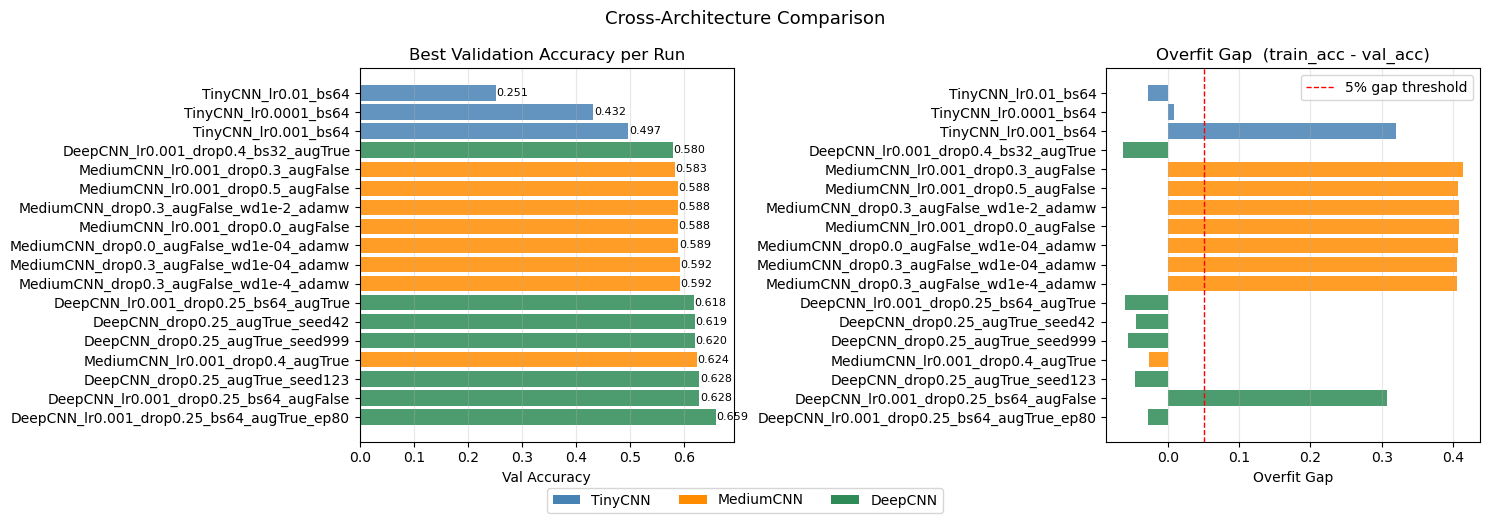

In [29]:
from matplotlib.patches import Patch

colors   = {'TinyCNN': 'steelblue', 'MediumCNN': 'darkorange', 'DeepCNN': 'seagreen'}
bar_clrs = [colors[a] for a in results_df['architecture']]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(results_df['run_name'], results_df['best_val_acc'], color=bar_clrs, alpha=0.85)
axes[0].set_title('Best Validation Accuracy per Run')
axes[0].set_xlabel('Val Accuracy')
axes[0].grid(True, axis='x', alpha=0.3)
for i, v in enumerate(results_df['best_val_acc']):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

axes[1].barh(results_df['run_name'], results_df['overfit_gap'], color=bar_clrs, alpha=0.85)
axes[1].axvline(0.05, color='red', linestyle='--', linewidth=1, label='5% gap threshold')
axes[1].set_title('Overfit Gap  (train_acc - val_acc)')
axes[1].set_xlabel('Overfit Gap')
axes[1].legend()
axes[1].grid(True, axis='x', alpha=0.3)

legend_elements = [Patch(facecolor=c, label=a) for a, c in colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Cross-Architecture Comparison', fontsize=13)
plt.tight_layout()
plt.show()


## W&B Report (ქართული)

ქვემოთ იქმნება chart-heavy რეპორტი `sansi23_team/FER-Challenge` პროექტში. არაფერს არ ამთვრებს — მხოლოდ არსებულ run-ებს კითხულობს.


In [ ]:
# Requires active wandb login (run the Wandb Setup cell first if this fails)
!pip install -q wandb-workspaces
wandb.login(relogin=True)
%run generate_wandb_report_ge.py
